# Thesis 
This document contains code pertaining to the figures in my Master's thesis.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mh
mh.style.use("ATLAS")
import awkward as ak
import torch 
import torch.nn as nn
plt.rcParams['font.size'] = 12
import torch.nn.functional as F 
import scipy.stats
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import pandas as pd
import spconv.pytorch as sp
import zuko as zk
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import vector as vec
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available
import statsmodels.api as sm
import ad_tools.tools as tools
from MLstatkit import Delong_test

/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/spconv/pytorch/functional.py:243: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated

# 3. Methodology

## 3.1 Calorimeter images with and without pileup suppression.

In [ ]:
jz0 = ak.from_parquet("/home/xzcapask/ad_trigger_data/JZ0_no_filter.parquet", columns = "cell_towers", row_groups=range(1))
jz0 = ak.to_numpy(jz0.cell_towers)
jz0_raw_image = jz0[0,:,:,2]
ggf = ak.from_parquet("/home/xzcapask/ad_trigger_data/ggF_SM_HH4b.parquet", columns = "cell_towers", row_groups=range(1))
ggf= ak.to_numpy(ggf.cell_towers)
hs = ak.from_parquet("/home/xzcapask/ad_trigger_data/HZ_bbvv.parquet", columns = "cell_towers", row_groups=range(1))
hs = ak.to_numpy(hs.cell_towers)

jz0_pileup_supressed = np.copy(jz0)
# JZ0 Pile Up Suppression
for i in range(len(jz0)):
    image_summed = np.sum(jz0_pileup_supressed[i], axis = -1)
    image_eta, image_phi = np.where(image_summed < 2)
    for j in range(len(image_eta)):      
        jz0_pileup_supressed[i,image_eta[j], image_phi[j],:] = 0 
jz0_pileup_supressed_image = jz0_pileup_supressed[0,:,:,2]

In [ ]:
sns.heatmap(data = jz0_raw_image)

In [ ]:
plt.imshow(jz0_raw_image)
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar(label = "Energy (Dimensionless)")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.savefig("/home/xzcapask/atlas_ad_hllhc/thesis/non_pileup_supressed_jz0.png")

In [ ]:
plt.imshow(jz0_pileup_supressed_image)
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar(label = "Energy (Dimensionless)")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.savefig("/home/xzcapask/atlas_ad_hllhc/thesis/pileup_supressed_jz0.png")

## 3.2 Standard Convolution vs Sparse Convolution

In [ ]:
conv = nn.Conv2d(in_channels=6, out_channels=6,kernel_size=3 , padding = 1)
inputs = torch.tensor(jz0_pileup_supressed[0].reshape(-1,50,64,6)).permute(dims = (0,3,1,2)).to(torch.float32)
result = conv(inputs)
fig,ax = plt.subplots(1,3, figsize=(20,15))

plot = ax[0].imshow(jz0_pileup_supressed[0,:,:,2])
ax[0].set_xlabel("$\phi$")
ax[0].set_ylabel("$\eta$")
ax[0].set_title(f"Original Image")

fig.colorbar(plot, ax = ax[0],shrink=0.2,label = "Energy (Dimensionless)")

j = 1 # counter
for i in range(1,6):
    result = F.relu(conv(inputs))
    inputs = result
    if i == 2 or i == 5:
        plot = ax[j].imshow(result.detach().numpy()[0][2])
        ax[j].set_xlabel("$\phi$")
        ax[j].set_ylabel("$\eta$")
        ax[j].set_title(f"{i} Convolutions")
        fig.colorbar(plot, ax = ax[j], shrink=0.2, label = "Energy (Dimensionless)")
        j+=1

In [ ]:
spconv = sp.SubMConv2d(in_channels=6,out_channels=6,kernel_size=3).to(device)
inputs2 = torch.tensor(jz0_pileup_supressed[0].reshape(-1,50,64,6)).permute(dims = (0,3,1,2)).to(torch.float32).to(device)

fig2,ax2 = plt.subplots(1,3, figsize=(20,15))
ax2[0].set_xlabel("$\phi$")
ax2[0].set_ylabel("$\eta$")
ax2[0].set_title(f"Original Image")

plot = ax2[0].imshow(jz0_pileup_supressed[0,:,:,2])
fig2.colorbar(plot, ax = ax2[0],shrink=0.2, label = "Energy (Dimensionless)")

j = 1 # counter
for i in range(1,6):
    inputs2 = torch.permute(inputs2, dims = (0,2,3,1))
    sparse_input = sp.SparseConvTensor.from_dense(inputs2)
    result2 = F.relu(spconv(sparse_input).dense())
    inputs2 = result2
    
    if i == 2 or i == 5: 
        print(i)
        plot = ax2[j].imshow(result2.cpu().detach().numpy()[0][2])
        ax2[j].set_xlabel("$\phi$")
        ax2[j].set_ylabel("$\eta$")
        ax2[j].set_title(f"{i} \n Submanifold Convolutions")
        fig2.colorbar(plot, ax = ax2[j],shrink=0.2, label = "Energy (Dimensionless)" )
        j+=1

# 4. Results and Discussion

## 4.1 ROC Curves

### ggf ROC curves

In [ ]:
# VAE 3 Shit
VAE3_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/jz0_kl_losses.npy")
VAE3_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/ggF_kl_losses.npy")
VAE3_vbf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/vbf_kl_losses.npy")
VAE3_hs_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/hs_kl_losses.npy")

In [ ]:
VAE3_jz0_ggf_losses = np.concatenate([VAE3_jz0_scores, VAE3_ggf_scores])

VAE3_truth_labels_ggf = np.concatenate([np.zeros_like(VAE3_jz0_scores), np.ones_like(VAE3_ggf_scores)])

In [ ]:
VAE3_fpr_ggf, VAE3_tpr_ggf, VAE3_threshold_ggf = roc_curve(VAE3_truth_labels_ggf, VAE3_jz0_ggf_losses)

In [ ]:
VAE3_auc_score_ggf = auc(VAE3_fpr_ggf,VAE3_tpr_ggf)
VAE3_auc_score_ggf

In [ ]:
spvae_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/jz0_kl_losses.npy")
spvae_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/ggF_kl_losses.npy")
spvae_vbf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/vbf_kl_losses.npy")
spvae_hs_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/hs_kl_losses.npy")

In [ ]:
spvae_jz0_ggf_losses = np.concatenate([spvae_jz0_scores, spvae_ggf_scores])
spvae_truth_labels_ggf = np.concatenate([np.zeros_like(spvae_jz0_scores), np.ones_like(spvae_ggf_scores)])

In [ ]:
spvae_fpr_ggf, spvae_tpr_ggf, spvae_threshold_ggf = roc_curve(spvae_truth_labels_ggf, spvae_jz0_ggf_losses)

In [ ]:
spvae_auc_score_ggf = auc(spvae_fpr_ggf,spvae_tpr_ggf)
spvae_auc_score_ggf

In [ ]:
nfvae_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/jz0_kl_losses.npy")
nfvae_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/ggF_kl_losses.npy")
nfvae_vbf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/vbf_kl_losses.npy")
nfvae_hs_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/hs_kl_losses.npy")

In [ ]:
nfvae_jz0_ggf_losses = np.concatenate([nfvae_jz0_scores, nfvae_ggf_scores])
nfvae_truth_labels_ggf = np.concatenate([np.zeros_like(nfvae_jz0_scores), np.ones_like(nfvae_ggf_scores)])

In [ ]:
nfvae_fpr_ggf, nfvae_tpr_ggf, nfvae_threshold_ggf = roc_curve(nfvae_truth_labels_ggf, nfvae_jz0_ggf_losses)

In [ ]:
nfvae_auc_score_ggf = auc(nfvae_fpr_ggf,nfvae_tpr_ggf)
nfvae_auc_score_ggf

In [ ]:
sns.lineplot(x = VAE3_fpr_ggf, y =  VAE3_tpr_ggf)

In [ ]:
plt.plot(VAE3_fpr_ggf,VAE3_tpr_ggf, label = "Baseline VAE: AUC = 0.94 ")
plt.plot(spvae_fpr_ggf,spvae_tpr_ggf, label = "SPVAE: AUC = 0.89")
plt.plot(nfvae_fpr_ggf,nfvae_tpr_ggf, label = "NFVAEL: AUC = 0.99 ")
plt.plot(np.linspace(0,1,20),np.linspace(0,1,20), "k--", label = "Random Guess")
plt.vlines(0.025, 0,1, "r", linestyles = "dashed", label = "Trigger Threshold")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.ylim(0,1)
plt.xlim(0,1)
plt.legend()
plt.savefig("ROC for ggf.png")

### vbf ROC curves

In [ ]:
VAE3_jz0_vbf_losses = np.concatenate([VAE3_jz0_scores, VAE3_vbf_scores])
VAE3_truth_labels_vbf = np.concatenate([np.zeros_like(VAE3_jz0_scores), np.ones_like(VAE3_vbf_scores)])
VAE3_fpr_vbf, VAE3_tpr_vbf, VAE3_threshold_vbf = roc_curve(VAE3_truth_labels_vbf, VAE3_jz0_vbf_losses)
VAE3_auc_score_vbf = auc(VAE3_fpr_vbf,VAE3_tpr_vbf)
VAE3_auc_score_vbf

In [ ]:
spvae_jz0_vbf_losses = np.concatenate([spvae_jz0_scores, spvae_vbf_scores])
spvae_truth_labels_vbf = np.concatenate([np.zeros_like(spvae_jz0_scores), np.ones_like(spvae_vbf_scores)])
spvae_fpr_vbf, spvae_tpr_vbf, spvae_threshold_vbf = roc_curve(spvae_truth_labels_vbf, spvae_jz0_vbf_losses)
spvae_auc_score_vbf = auc(spvae_fpr_vbf,spvae_tpr_vbf)
spvae_auc_score_vbf

In [ ]:
nfvae_jz0_vbf_losses = np.concatenate([nfvae_jz0_scores, nfvae_vbf_scores])
nfvae_truth_labels_vbf = np.concatenate([np.zeros_like(nfvae_jz0_scores), np.ones_like(nfvae_vbf_scores)])
nfvae_fpr_vbf, nfvae_tpr_vbf, nfvae_threshold_vbf = roc_curve(nfvae_truth_labels_vbf, nfvae_jz0_vbf_losses)
nfvae_auc_score_vbf = auc(nfvae_fpr_vbf,nfvae_tpr_vbf)
nfvae_auc_score_vbf

In [ ]:
plt.plot(VAE3_fpr_vbf,VAE3_tpr_vbf, label = "Baseline VAE 3: AUC 0.90")
plt.plot(spvae_fpr_vbf,spvae_tpr_vbf, label = "SPVAE: AUC 0.84")
plt.plot(nfvae_fpr_vbf,nfvae_tpr_vbf, label = "NFVAE: AUC 0.98")
plt.plot(np.linspace(0,1,20),np.linspace(0,1,20), "k--", label = "Random Guess")
plt.vlines(0.025, 0,1, "r", linestyles = "dashed", label = "Trigger Threshold")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.ylim(0,1)
plt.xlim(0,1)
plt.savefig("ROC for vbf.png")

### hs ROC curves

In [ ]:
VAE3_jz0_hs_losses = np.concatenate([VAE3_jz0_scores, VAE3_hs_scores])
VAE3_truth_labels_hs = np.concatenate([np.zeros_like(VAE3_jz0_scores), np.ones_like(VAE3_hs_scores)])
VAE3_fpr_hs, VAE3_tpr_hs, VAE3_threshold_hs = roc_curve(VAE3_truth_labels_hs, VAE3_jz0_hs_losses)
VAE3_auc_score_hs = auc(VAE3_fpr_hs,VAE3_tpr_hs)
VAE3_auc_score_hs

In [ ]:
spvae_jz0_hs_losses = np.concatenate([spvae_jz0_scores, spvae_hs_scores])
spvae_truth_labels_hs = np.concatenate([np.zeros_like(spvae_jz0_scores), np.ones_like(spvae_hs_scores)])
spvae_fpr_hs, spvae_tpr_hs, spvae_threshold_hs = roc_curve(spvae_truth_labels_hs, spvae_jz0_hs_losses)
spvae_auc_score_hs = auc(spvae_fpr_hs,spvae_tpr_hs)
spvae_auc_score_vbf

In [ ]:
nfvae_jz0_hs_losses = np.concatenate([nfvae_jz0_scores, nfvae_hs_scores])
nfvae_truth_labels_hs = np.concatenate([np.zeros_like(nfvae_jz0_scores), np.ones_like(nfvae_hs_scores)])
nfvae_fpr_hs, nfvae_tpr_hs, nfvae_threshold_hs = roc_curve(nfvae_truth_labels_hs, nfvae_jz0_hs_losses)
nfvae_auc_score_hs = auc(nfvae_fpr_hs,nfvae_tpr_hs)
nfvae_auc_score_hs

In [ ]:
plt.plot(VAE3_fpr_hs,VAE3_tpr_hs, label = "VAE 3")
plt.plot(spvae_fpr_hs,spvae_tpr_hs, label = "SPVAE")
plt.plot(nfvae_fpr_hs,nfvae_tpr_hs, label = "NFVAE")
plt.plot(np.linspace(0,1,20),np.linspace(0,1,20), "k--", label = "Random Guess")
plt.vlines(0.025, 0,1, "r", linestyles = "dashed", label = "Trigger Threshold")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.ylim(0,1)
plt.xlim(0,1)
plt.savefig("ROC for hs.png")

## 4.2 JZ0 Reconstructions

In [ ]:
# Image preprocessing
jz0 = ak.from_parquet("/home/xzcapask/ad_trigger_data/JZ0_no_filter.parquet", columns = "cell_towers", row_groups=range(1))
jz0 = ak.to_numpy(jz0.cell_towers)
ggf = ak.from_parquet("/home/xzcapask/ad_trigger_data/ggF_SM_HH4b.parquet", columns = "cell_towers", row_groups=range(1))
ggf= ak.to_numpy(ggf.cell_towers)
hs = ak.from_parquet("/home/xzcapask/ad_trigger_data/HZ_bbvv.parquet", columns = "cell_towers", row_groups=range(1))
hs = ak.to_numpy(hs.cell_towers)

jz0_pileup_supressed = np.copy(jz0)
# JZ0 Pile Up Suppression
for i in range(len(jz0)):
    jz0_image_summed = np.sum(jz0_pileup_supressed[i], axis = -1)
    jz0_image_eta, jz0_image_phi = np.where(jz0_image_summed < 2)
    for j in range(len(jz0_image_eta)):      
        jz0_pileup_supressed[i,jz0_image_eta[j], jz0_image_phi[j],:] = 0 
jz0_rms_energy = 0.0955
jz0_inputs = torch.tensor(jz0_pileup_supressed).permute(dims = (0,3,1,2)).to(torch.float32)
jz0_inputs= jz0_inputs / jz0_rms_energy
jz0_input_image = jz0_inputs[0]

ggf_pileup_supressed = np.copy(ggf)
# JZ0 Pile Up Suppression
for i in range(len(ggf)):
    ggf_image_summed = np.sum(ggf_pileup_supressed[i], axis = -1)
    ggf_image_eta, ggf_image_phi = np.where(ggf_image_summed < 2)
    for j in range(len(ggf_image_eta)):      
        ggf_pileup_supressed[i,ggf_image_eta[j], ggf_image_phi[j],:] = 0 
ggf_inputs = torch.tensor(ggf_pileup_supressed).permute(dims = (0,3,1,2)).to(torch.float32)
ggf_inputs= ggf_inputs / jz0_rms_energy
ggf_input_image = ggf_inputs[0]

In [ ]:
class BetaVAEMark3Encoder(nn.Module):
    """
    Beta VAE Mark 3 Encoder 
    """
    def __init__(self, latent_dim = 4, log_clamping = True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))
        self.log_clamping = log_clamping


    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        mu = self.mu(output13)
        logvar = self.logvar(output13)
        if self.log_clamping:
            pass
        
        return mu, logvar,indices1,indices2,indices3

    
class BetaVAEMark3Decoder(nn.Module):
    """
    Beta VAE Mark 3  Decoder.
    """
    def __init__(self, latent_dim = 4):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11,indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15
    
class BetaVAEMark3(nn.Module):
    """
    Beta VAE Mark 3.
    """

    def __init__(self, latent_dim = 4, log_clamping = True):
        super().__init__()
        self.encoder = BetaVAEMark3Encoder(latent_dim = latent_dim, log_clamping = log_clamping)
        self.decoder = BetaVAEMark3Decoder(latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z, indices1, indices2, indices3)
        return output, mu, logvar,z


# Loading Model
jz0_inputs = jz0_inputs.to(device)
VAE3 = BetaVAEMark3(latent_dim = 4).to(device)
VAE3.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/weights/BetaVAEMark3L4_weights_epoch100.pth",map_location=torch.device('cpu')))

# Output
VAE3_outputs = VAE3(jz0_inputs)
VAE3_output = VAE3_outputs[0][0].cpu().detach().numpy()

In [ ]:
plt.imshow(jz0_input_image[1])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")
plt.savefig("Input JZ0 Image.png")

In [ ]:
plt.imshow(VAE3_output[1])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")
plt.savefig("Output Baseline VAE JZ0 Image.png")

In [ ]:
VAE3_ggf_outputs = VAE3(ggf_inputs.to(device))
VAE3_ggf_output = VAE3_ggf_outputs[0][0].cpu().detach().numpy()

In [ ]:
plt.imshow(ggf_input_image[2])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")

In [ ]:
plt.imshow(VAE3_ggf_output[2])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")
plt.savefig("Output Baseline VAE JZ0 Image.png")

In [ ]:
class SparseVAE2(nn.Module):
    """
    Sparse VAE.
    """

    def __init__(self, latent_dim = 4):
        super().__init__()

        # Encoder
        self.subspconv1 = sp.SubMConv2d(in_channels = 6, out_channels = 8, kernel_size = 3)
        self.sppool1 = sp.SparseMaxPool2d(kernel_size= 2, stride = 2, indice_key="1")
        self.subspconv2 = sp.SubMConv2d(in_channels = 8, out_channels = 16, kernel_size = 3)
        self.sppool2 = sp.SparseMaxPool2d(kernel_size= (5,2), stride = (5,2), indice_key="2")
        self.subspconv3 = sp.SubMConv2d(in_channels = 16, out_channels = 32, kernel_size = 3)
        self.sppool3 = sp.SparseMaxPool2d(kernel_size= (5,2), stride = (5,2), indice_key="3")
        self.mu = sp.SparseConv2d(in_channels = 32, out_channels = 1, kernel_size = (1,5), indice_key = "4")
        self.logvar = sp.SparseConv2d(in_channels = 32, out_channels = 1, kernel_size = (1,5))

        # Decoder
        self.unsppool = sp.SparseInverseConv2d(in_channels = 1, out_channels= 32, kernel_size = (1,5), indice_key="4")
        self.unsppool1 = sp.SparseInverseConv2d(in_channels = 32, out_channels = 32, kernel_size = (5,2), indice_key="3")
        self.subspconv4 = sp.SubMConv2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3)
        
        self.unsppool2 = sp.SparseInverseConv2d(in_channels = 16, out_channels = 16, kernel_size = (5,2), indice_key="2")
        self.subspconv5 = sp.SubMConv2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3)
        
        self.unsppool3 = sp.SparseInverseConv2d(in_channels = 8, out_channels = 8,kernel_size = 2, indice_key="1")
        self.subspconv6 = sp.SubMConv2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3)


    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
  

    def forward(self, input):
        # Converting to sparse tensor
        input = torch.permute(input, dims = (0,2,3,1))
        input = sp.SparseConvTensor.from_dense(input)

        # Convolution Block 1
        output1 = self.subspconv1(input)
        output2 = output1.replace_feature(F.leaky_relu(output1.features))
        output3 = self.sppool1(output2)



        # Convolutional Block 2
        output4 = self.subspconv2(output3)
        output5 = output4.replace_feature(F.leaky_relu(output4.features))
        output6 = self.sppool2(output5)



        # Convolutional Block 3
        output7 = self.subspconv3(output6)
        output8 = output7.replace_feature(F.leaky_relu(output7.features))
        output9 = self.sppool3(output8)

        # Latent space mapping and reparametrisation
        mu = self.mu(output9)
        logvar = self.logvar(output9)
        z = self.reparameterise(mu.features, logvar.features)
        z = mu.replace_feature(z)


        # Reconstructing the sparse tensor
        output10 = self.unsppool(z)
        output10 = output10.replace_feature(F.leaky_relu(output10.features))
        output12 = self.unsppool1(output10)
        output12 = output12.replace_feature(F.leaky_relu(output12.features))
        output13 = self.subspconv4(output12)
        output13 = output13.replace_feature(F.leaky_relu(output13.features))
        output14 = self.unsppool2(output13)
        output14 = output14.replace_feature(F.leaky_relu(output14.features))
        output15 = self.subspconv5(output14)
        output15 = output15.replace_feature(F.leaky_relu(output15.features))
        output16 = self.unsppool3(output15)
        output16 = output16.replace_feature(F.leaky_relu(output16.features))
        output17 = self.subspconv6(output16)
        output17 = output17.replace_feature(F.leaky_relu(output17.features))


        return output17.dense(), torch.flatten(mu.dense(), start_dim = 1), torch.flatten(logvar.dense(), start_dim = 1),torch.flatten(z.dense(), start_dim = 1)
    
spvae = SparseVAE2().to(device)
spvae.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/weights/SparseVAE2_weights_epoch100.pth"))

# Output
jz0_inputs = jz0_inputs.to(device)
spvae_outputs = spvae(jz0_inputs)
spvae_output = spvae_outputs[0][0].cpu().detach().numpy()

In [ ]:
plt.imshow(spvae_output[1])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")
plt.savefig("Output spvae JZ0 Image.png")

In [ ]:
class NFVAEEncoder(nn.Module):
    """
    NF-VAE Encoder 
    """
    def __init__(self, latent_dim = 4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))





    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        mu = self.mu(output13)
        logvar = self.logvar(output13)



        return mu, logvar,indices1,indices2,indices3
    
class NFVAEDecoder(nn.Module):
    """
    NF-VAE Decoder.
    """
    def __init__(self, latent_dim = 4):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11, indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15

class NFVAE(nn.Module):
    """
    NF-VAE using RealNVP
    """

    def __init__(self,latent_dim = 4):
        super().__init__()
        self.encoder = NFVAEEncoder(latent_dim = latent_dim)
        self.decoder = NFVAEDecoder(latent_dim = latent_dim)
        self.flow = zk.flows.NSF(features = latent_dim, transforms = 10, bins = 4, hidden_features = [latent_dim * 4, latent_dim * 4])

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        std = torch.exp(0.5 * logvar)
        z0 = self.reparameterise(mu, logvar)



        q0 = torch.distributions.Normal(mu, std)

        # Flow transformation
        transform = self.flow().transform
        z = transform(z0)
        log_det = transform.log_abs_det_jacobian(z0, z)

        # KL loss calculation
        p = torch.distributions.Normal(torch.zeros_like(z), torch.ones_like(z)) # Prior
        log_q0 = torch.sum(q0.log_prob(z0), dim=-1)
        log_p = torch.sum(p.log_prob(z), dim=-1)
        kld = log_q0 - log_det - log_p

        # Decoder Output
        output = self.decoder(z, indices1, indices2, indices3)
        return output,mu,logvar,kld,z
    

nfvae = NFVAE(latent_dim=4).to(device)
nfvae.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/weights/NFVAEL4_weights_epoch100.pth"))

# Output
jz0_inputs = jz0_inputs.to(device)
nfvae_outputs = nfvae(jz0_inputs)
nfvae_output = nfvae_outputs[0][0].cpu().detach().numpy()

In [ ]:
plt.imshow(nfvae_output[1])
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
mh.atlas.label('- Work In Progress',loc=0, com = 14)
plt.colorbar(label = "Energy (Dimensionless)")
plt.savefig("Output nfvae JZ0 Image.png")

## 4.3 t-SNE plots

In [23]:
baselinevae_ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/latent_vectors/ggF_latent_codes.npy").reshape(50000,4)
baselinevae_vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/latent_vectors/vbf_latent_codes.npy").reshape(50000,4)
baselinevae_hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/latent_vectors/hs_latent_codes.npy").reshape(50000,4)
baselinevae_jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/latent_vectors/jz0_latent_codes.npy").reshape(49000,4)



In [24]:
nfvae_ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/latent_vectors/ggF_latent_codes.npy").reshape(50000,4)
nfvae_vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/latent_vectors/vbf_latent_codes.npy").reshape(50000,4)
nfvae_hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/latent_vectors/hs_latent_codes.npy").reshape(50000,4)
nfvae_jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/latent_vectors/jz0_latent_codes.npy").reshape(49000,4)

In [25]:
scaler = StandardScaler()
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

In [26]:
nf_ggf_scaled = scaler.fit_transform(nfvae_ggf_latent_codes[:10000])
nfvae_ggf_tsne = tsne.fit_transform(nf_ggf_scaled)
nfvae_jz0_scaled = scaler.fit_transform(nfvae_jz0_latent_codes[:10000])
jz0_tsne = tsne.fit_transform(nfvae_jz0_scaled)
nfvae_vbf_scaled = scaler.fit_transform(nfvae_vbf_latent_codes[:10000])
nfvae_vbf_tsne = tsne.fit_transform(nfvae_vbf_latent_codes)
nfvae_hs_scaled = scaler.fit_transform(nfvae_hs_latent_codes[:10000])
nfvae_hs_tsne = tsne.fit_transform(nfvae_hs_latent_codes)

In [27]:
plt.scatter(nf_vbf_tsne[:,0],nf_vbf_tsne[:,1], label = "VBF")
plt.scatter(jz0_tsne[:,0],jz0_tsne[:,1], label = "JZ0")
plt.scatter(nf_ggf_tsne[:,0],nf_ggf_tsne[:,1], label = "ggF")
plt.scatter(nf_hs_latent_codes[:,0],nf_hs_latent_codes[:,1], label = "HS")


plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D T-SNE Plot of 4D Latent Space")
plt.legend()

NameError: name 'nf_vbf_tsne' is not defined

# 4.4 Chi squared Analysis

In [ ]:
jz0_chi = np.sum(baselinevae_jz0_latent_codes**2, axis = 1)
chi = np.random.chisquare(4, 49000)

In [ ]:
plt.hist(jz0_chi, bins = 1000, range = (0,10), histtype= "step",density = True, label = "Actual Distribution")
plt.hist(chi, bins = 1000, histtype= "step", range = (0,10), density = True, label = "Expected Distribution")
plt.legend()
plt.xlabel("$\chi^2$")
plt.savefig("")

## 4.5 MET/HT VS Anomaly Score Analysis

### 4.5.1 VAE 3

In [ ]:
VAE3_mte_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/mte_of_unregistered_hs_signals.npy")
VAE3_mte_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/mte_of_registered_hs_signals.npy")
VAE3_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/hs_kl_losses.npy")
VAE3_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/KLCutoff.npy")
VAE3_losses_of_accepted_events = VAE3_hs_losses[VAE3_hs_losses >= VAE3_klcutoff]
VAE3_losses_of_rejected_events = VAE3_hs_losses[VAE3_hs_losses < VAE3_klcutoff]
VAE3_losses = np.concatenate([VAE3_losses_of_rejected_events, VAE3_losses_of_accepted_events])
VAE3_mte_hs = np.concatenate([VAE3_mte_hs_unregistered, VAE3_mte_hs_registered])
scipy.stats.spearmanr(VAE3_mte_hs,VAE3_losses)

In [ ]:
VAE3_mte_hs = pd.DataFrame(data = VAE3_mte_hs, columns = ["mte_hs"])
VAE3_mte_hs["Anomaly Score"] = VAE3_losses
VAE3_mte_hs

In [ ]:
lowess_data = sm.nonparametric.lowess(VAE3_mte_hs["mte_hs"],VAE3_mte_hs["Anomaly Score"], frac = 0.3)

In [ ]:
#ax = sns.histplot(x='mte_hs', y= "Anomaly Score", data = VAE3_mte_hs, cbar = True,binrange=((0, 200),(0,1)), bins = 20)
plt.plot(lowess_data[:,0],lowess_data[:,1])

In [ ]:
sns.lmplot(x='mte_hs', y= "Anomaly Score", data = VAE3_mte_hs,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,250)
plt.xlim(0,1000)
plt.legend()

In [ ]:
sns.histplot(x='mte_hs', y= "Anomaly Score", data = VAE3_mte_hs, bins = 1000, cbar = True)
plt.xlim(0,200)
plt.ylim(0,100)

### 4.5.2 SPVAE

In [ ]:
spvae_mte_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/mte_of_unregistered_hs_signals.npy")
spvae_mte_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/mte_of_registered_hs_signals.npy")
spvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/hs_kl_losses.npy")
spvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/KLCutoff.npy")
spvae_losses_of_accepted_events = spvae_hs_losses[spvae_hs_losses >= spvae_klcutoff]
spvae_losses_of_rejected_events = spvae_hs_losses[spvae_hs_losses < spvae_klcutoff]
spvae_losses = np.concatenate((spvae_losses_of_rejected_events, spvae_losses_of_accepted_events))
spvae_mte_hs = np.concatenate((spvae_mte_hs_unregistered, spvae_mte_hs_registered))
scipy.stats.spearmanr(spvae_mte_hs,spvae_losses)

In [ ]:
spvae_mte_hs = pd.DataFrame(data = spvae_mte_hs, columns = ["mte_hs"])
spvae_mte_hs["Anomaly Score"] = VAE3_losses
spvae_mte_hs

In [ ]:
sns.lmplot(x='mte_hs', y= "Anomaly Score", data = spvae_mte_hs,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.ylim(0,)
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,100)
plt.xlim(0,800)
plt.legend()

### 4.5.3 NF-VAE

In [ ]:
nfvae_mte_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/mte_of_unregistered_hs_signals.npy")
nfvae_mte_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/mte_of_registered_hs_signals.npy")
nfvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/hs_kl_losses.npy")
nfvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/KLCutoff.npy")
nfvae_losses_of_accepted_events = nfvae_hs_losses[nfvae_hs_losses >= nfvae_klcutoff]
nfvae_losses_of_rejected_events = nfvae_hs_losses[nfvae_hs_losses < nfvae_klcutoff]
nfvae_losses = np.concatenate([nfvae_losses_of_rejected_events, nfvae_losses_of_accepted_events])
nfvae_mte_hs = np.concatenate([nfvae_mte_hs_unregistered, nfvae_mte_hs_registered])
scipy.stats.spearmanr(nfvae_mte_hs,nfvae_losses)

In [ ]:
nfvae_mte_hs = pd.DataFrame(data = nfvae_mte_hs, columns = ["mte_hs"])
nfvae_mte_hs["Anomaly Score"] = VAE3_losses
nfvae_mte_hs

In [ ]:
sns.lmplot(x='mte_hs', y= "Anomaly Score", data = nfvae_mte_hs,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,100)
plt.xlim(0,800)
plt.legend()

## 4.6 HT VS Anomaly Score Analysis

### 4.6.1 Baseline VAE

In [ ]:
VAE3_ht_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_registered_ggf_signals.npy")
VAE3_ht_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_unregistered_ggf_signals.npy") 
VAE3_ggf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/ggF_kl_losses.npy")
VAE3_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/KLCutoff.npy")
VAE3_losses_of_accepted_ggf_events = VAE3_ggf_losses[VAE3_ggf_losses >= VAE3_klcutoff]
VAE3_losses_of_rejected_ggf_events = VAE3_ggf_losses[VAE3_ggf_losses < VAE3_klcutoff]
VAE3_ggf_losses = np.concatenate((VAE3_losses_of_rejected_ggf_events, VAE3_losses_of_accepted_ggf_events))
VAE3_ht_ggf = np.concatenate((VAE3_ht_ggf_unregistered, VAE3_ht_ggf_registered))
scipy.stats.spearmanr(VAE3_ht_ggf,VAE3_ggf_losses)

In [ ]:
VAE3_ht_ggf_data = pd.DataFrame(data = VAE3_ht_ggf, columns = ["ht_ggf"])
VAE3_ht_ggf_data["Anomaly Score"] = VAE3_ggf_losses
VAE3_ht_ggf_data

In [ ]:
sns.lmplot(x='ht_ggf', y= "Anomaly Score", data = VAE3_ht_ggf_data,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.ylim(0,700)
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,250)
plt.xlim(0,1000)
plt.legend()

In [ ]:
VAE3_ht_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_registered_vbf_signals.npy")
VAE3_ht_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_unregistered_vbf_signals.npy") 
VAE3_vbf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/vbf_kl_losses.npy")
VAE3_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/KLCutoff.npy")
VAE3_losses_of_accepted_vbf_events = VAE3_vbf_losses[VAE3_vbf_losses >= VAE3_klcutoff]
VAE3_losses_of_rejected_vbf_events = VAE3_vbf_losses[VAE3_vbf_losses < VAE3_klcutoff]
VAE3_vbf_losses = np.concatenate([VAE3_losses_of_rejected_vbf_events, VAE3_losses_of_accepted_vbf_events])
VAE3_ht_vbf = np.concatenate([VAE3_ht_vbf_unregistered, VAE3_ht_vbf_registered])
scipy.stats.spearmanr(VAE3_ht_vbf,VAE3_vbf_losses)

In [ ]:
VAE3_ht_vbf_data = pd.DataFrame(data = VAE3_ht_vbf, columns = ["ht_vbf"])
VAE3_ht_vbf_data["Anomaly Score"] = VAE3_vbf_losses
VAE3_ht_vbf_data

In [ ]:
VAE3_ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_registered_hs_signals.npy")
VAE3_ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/ht_of_unregistered_hs_signals.npy") 
VAE3_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/hs_kl_losses.npy")
VAE3_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/KLCutoff.npy")
VAE3_losses_of_accepted_hs_events = VAE3_hs_losses[VAE3_hs_losses >= VAE3_klcutoff]
VAE3_losses_of_rejected_hs_events = VAE3_hs_losses[VAE3_hs_losses < VAE3_klcutoff]
VAE3_hs_losses = np.concatenate([VAE3_losses_of_rejected_hs_events, VAE3_losses_of_accepted_hs_events])
VAE3_ht_hs = np.concatenate([VAE3_ht_hs_unregistered, VAE3_ht_hs_registered])
scipy.stats.spearmanr(VAE3_ht_hs,VAE3_hs_losses)

In [ ]:
VAE3_ht_all_events_losses = np.concatenate([VAE3_ggf_losses, VAE3_vbf_losses, VAE3_hs_losses])
VAE3_ht = np.concatenate([VAE3_ht_ggf, VAE3_ht_vbf, VAE3_ht_hs])
scipy.stats.spearmanr(VAE3_ht,VAE3_ht_all_events_losses)

In [ ]:
VAE3_ht_data = pd.DataFrame(data = VAE3_ht, columns = ["ht"])
VAE3_ht_data["Anomaly Score"] = VAE3_ht_all_events_losses
VAE3_ht_data

In [ ]:
sns.histplot(x='ht', y= "Anomaly Score", data = VAE3_ht_data,cbar=True, binrange = ((0,1000),(0,100)))
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylim(0,2)
plt.xlim(0,400)

In [ ]:
sns.lmplot(x='ht', y= "Anomaly Score", data = VAE3_ht_data,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,250)
plt.xlim(0,1000)
plt.legend()

### 4.6.2 SPVAE

In [ ]:
spvae_ht_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_registered_ggf_signals.npy")
spvae_ht_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_unregistered_ggf_signals.npy") 
spvae_ggf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/ggF_kl_losses.npy")
spvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/KLCutoff.npy")
spvae_losses_of_accepted_ggf_events = spvae_ggf_losses[spvae_ggf_losses >= spvae_klcutoff]
spvae_losses_of_rejected_ggf_events = spvae_ggf_losses[spvae_ggf_losses < spvae_klcutoff]
spvae_ggf_losses = np.concatenate((spvae_losses_of_rejected_ggf_events, spvae_losses_of_accepted_ggf_events))
spvae_ht_ggf = np.concatenate((spvae_ht_ggf_unregistered, spvae_ht_ggf_registered))
scipy.stats.spearmanr(spvae_ht_ggf,spvae_ggf_losses)

In [ ]:
spvae_ht_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_registered_vbf_signals.npy")
spvae_ht_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_unregistered_vbf_signals.npy") 
spvae_vbf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/vbf_kl_losses.npy")
spvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/KLCutoff.npy")
spvae_losses_of_accepted_vbf_events = spvae_vbf_losses[spvae_vbf_losses >= spvae_klcutoff]
spvae_losses_of_rejected_vbf_events = spvae_vbf_losses[spvae_vbf_losses < spvae_klcutoff]
spvae_vbf_losses = np.concatenate((spvae_losses_of_rejected_vbf_events, spvae_losses_of_accepted_vbf_events))
spvae_ht_vbf = np.concatenate((spvae_ht_vbf_unregistered, spvae_ht_vbf_registered))
scipy.stats.spearmanr(spvae_ht_vbf,spvae_vbf_losses)

In [ ]:
spvae_ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_registered_hs_signals.npy")
spvae_ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/ht_of_unregistered_hs_signals.npy") 
spvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/hs_kl_losses.npy")
spvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/KLCutoff.npy")
spvae_losses_of_accepted_hs_events = spvae_hs_losses[spvae_hs_losses >= spvae_klcutoff]
spvae_losses_of_rejected_hs_events = spvae_hs_losses[spvae_hs_losses < spvae_klcutoff]
spvae_hs_losses = np.concatenate((spvae_losses_of_rejected_hs_events, spvae_losses_of_accepted_hs_events))
spvae_ht_hs = np.concatenate((spvae_ht_hs_unregistered, spvae_ht_hs_registered))
scipy.stats.spearmanr(spvae_ht_hs,spvae_hs_losses)

In [ ]:
spvae_ht_all_events_losses = np.concatenate([spvae_ggf_losses, spvae_vbf_losses, spvae_hs_losses])
spvae_ht = np.concatenate([spvae_ht_ggf, spvae_ht_vbf, spvae_ht_hs])
scipy.stats.spearmanr(spvae_ht,spvae_ht_all_events_losses)

In [ ]:
spvae_ht_data = pd.DataFrame(data = spvae_ht, columns = ["ht"])
spvae_ht_data["Anomaly Score"] = spvae_ht_all_events_losses
spvae_ht_data

In [ ]:
sns.lmplot(x='ht', y= "Anomaly Score", data = spvae_ht_data,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.31$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")

plt.legend()

### 4.6.3 NFVAE

In [ ]:
nfvae_ht_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_registered_ggf_signals.npy")
nfvae_ht_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_unregistered_ggf_signals.npy") 
nfvae_ggf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/ggF_kl_losses.npy")
nfvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/KLCutoff.npy")
nfvae_losses_of_accepted_ggf_events = nfvae_ggf_losses[nfvae_ggf_losses >= nfvae_klcutoff]
nfvae_losses_of_rejected_ggf_events = nfvae_ggf_losses[nfvae_ggf_losses < nfvae_klcutoff]
nfvae_ggf_losses = np.concatenate((nfvae_losses_of_rejected_ggf_events, nfvae_losses_of_accepted_ggf_events))
nfvae_ht_ggf = np.concatenate((nfvae_ht_ggf_unregistered, nfvae_ht_ggf_registered))
scipy.stats.spearmanr(nfvae_ht_ggf,nfvae_ggf_losses)

In [ ]:
nfvae_ht_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_registered_vbf_signals.npy")
nfvae_ht_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_unregistered_vbf_signals.npy") 
nfvae_vbf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/vbf_kl_losses.npy")
nfvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/KLCutoff.npy")
nfvae_losses_of_accepted_vbf_events = nfvae_vbf_losses[nfvae_vbf_losses >= nfvae_klcutoff]
nfvae_losses_of_rejected_vbf_events = nfvae_vbf_losses[nfvae_vbf_losses < nfvae_klcutoff]
nfvae_vbf_losses = np.concatenate((nfvae_losses_of_rejected_vbf_events, nfvae_losses_of_accepted_vbf_events))
nfvae_ht_vbf = np.concatenate((nfvae_ht_vbf_unregistered, nfvae_ht_vbf_registered))
scipy.stats.spearmanr(nfvae_ht_vbf,nfvae_vbf_losses)

In [ ]:
nfvae_ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_registered_hs_signals.npy")
nfvae_ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/ht_of_unregistered_hs_signals.npy") 
nfvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/hs_kl_losses.npy")
nfvae_klcutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/KLCutoff.npy")
nfvae_losses_of_accepted_hs_events = nfvae_hs_losses[nfvae_hs_losses >= nfvae_klcutoff]
nfvae_losses_of_rejected_hs_events = nfvae_hs_losses[nfvae_hs_losses < nfvae_klcutoff]
nfvae_hs_losses = np.concatenate((nfvae_losses_of_rejected_hs_events, nfvae_losses_of_accepted_hs_events))
nfvae_ht_hs = np.concatenate((nfvae_ht_hs_unregistered, nfvae_ht_hs_registered))
scipy.stats.spearmanr(nfvae_ht_hs,nfvae_hs_losses)

In [ ]:
nfvae_ht_all_events_losses = np.concatenate([nfvae_ggf_losses, nfvae_vbf_losses, nfvae_hs_losses])
nfvae_ht = np.concatenate([nfvae_ht_ggf, nfvae_ht_vbf, nfvae_ht_hs])
scipy.stats.spearmanr(nfvae_ht,nfvae_ht_all_events_losses)

In [ ]:
nfvae_ht_data = pd.DataFrame(data = nfvae_ht, columns = ["ht"])
nfvae_ht_data["Anomaly Score"] = nfvae_ht_all_events_losses
nfvae_ht_data

In [ ]:
sns.lmplot(x='ht', y= "Anomaly Score", data = nfvae_ht_data,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={'color': 'red',"label": "$r_s = 0.76$", "linestyle":"--"}, height=5, aspect=1.2, lowess=True)
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.ylabel("KL Divergence")
plt.xlabel(r"$\frac{E^{miss}_T}{H_T}$")
plt.ylim(0,250)
plt.xlim(0,1000)
plt.legend()

## 4.7et Multiplicity Analysis

In [ ]:
ggf_info = ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/ggF_SM_HH4b.parquet", columns = "AntiKt4TruthDressedWZJets", row_groups = range(50))
vbf_info = ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/VBF_SM_HH4b.parquet", columns = "AntiKt4TruthDressedWZJets", row_groups = range(50))
hs_info = ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/HZ_bbvv.parquet", columns = "AntiKt4TruthDressedWZJets", row_groups = range(50))

In [ ]:
VAE3_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/jz0_kl_losses.npy")
VAE3_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/ggF_kl_losses.npy")
VAE3_vbf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/vbf_kl_losses.npy")
VAE3_hs_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/hs_kl_losses.npy")

In [ ]:
ggf_jets = np.zeros(50000) 
for i in range(50000):
    num_of_jets = len(ggf_info.AntiKt4TruthDressedWZJets[i])
    ggf_jets[i] = num_of_jets

vbf_jets = np.zeros(50000) 
for i in range(50000):
    num_of_jets = len(vbf_info.AntiKt4TruthDressedWZJets[i])
    vbf_jets[i] = num_of_jets

hs_jets = np.zeros(50000) 
for i in range(50000):
    num_of_jets = len(hs_info.AntiKt4TruthDressedWZJets[i])
    hs_jets[i] = num_of_jets

In [ ]:
VAE3_losses = np.concatenate([VAE3_ggf_scores,VAE3_vbf_scores ,VAE3_hs_scores])
jets = np.concatenate([ggf_jets,vbf_jets,hs_jets])
scipy.stats.spearmanr(VAE3_losses,jets)

In [ ]:
spvae_ggf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/ggF_kl_losses.npy")
spvae_vbf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/vbf_kl_losses.npy")
spvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/hs_kl_losses.npy")

spvae_losses = np.concatenate([spvae_ggf_losses,spvae_vbf_losses ,spvae_hs_losses])
jets = np.concatenate([ggf_jets,vbf_jets,hs_jets])
scipy.stats.spearmanr(spvae_losses,jets)

In [ ]:
nfvae_ggf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/ggF_kl_losses.npy")
nfvae_vbf_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/vbf_kl_losses.npy")
nfvae_hs_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/hs_kl_losses.npy")

nfvae_losses = np.concatenate([nfvae_ggf_losses,nfvae_vbf_losses ,nfvae_hs_losses])
jets = np.concatenate([ggf_jets,vbf_jets,hs_jets])
scipy.stats.spearmanr(nfvae_losses,jets)

In [ ]:
plt.plot(nfvae_losses,jets,".")

## 4.8 Pileup Suppression Studies

In [ ]:
ggf_pileup_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/pileup/ggf_pileup_signal_acceptance.npy")
vbf_pileup_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/pileup/vbf_pileup_signal_acceptance.npy")
hs_pileup_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/pileup/hs_pileup_signal_acceptance.npy")

In [ ]:
plt.plot(np.arange(0,4.1,0.1), ggf_pileup_scores, ".")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)

In [ ]:
df = pd.DataFrame(data = ggf_pileup_scores, columns = ["ggf"])
df["pileup_suppression"] = np.arange(0,4.1,0.1)

In [ ]:
df["vbf"] = vbf_pileup_scores
df["hs"] = hs_pileup_scores

In [ ]:
lowess_data = sm.nonparametric.lowess(df["ggf"],df["pileup_suppression"], frac = 0.3)

In [ ]:
lowess_data2 = sm.nonparametric.lowess(df["vbf"],df["pileup_suppression"], frac = 0.3)

In [ ]:
lowess_data3 = sm.nonparametric.lowess(df["hs"],df["pileup_suppression"], frac = 0.3)

In [ ]:
plt.plot(df["pileup_suppression"],df["ggf"],".")
plt.plot(lowess_data[:,0],lowess_data[:,1], label= "ggf")
plt.plot(df["pileup_suppression"],df["ggf"],".")
"""
plt.plot(lowess_data2[:,0],lowess_data2[:,1], label= "vbf")
plt.plot(lowess_data3[:,0],lowess_data3[:,1], label= "hs")
"""
plt.xlabel("Pileup suppression (GeV)")
plt.ylabel("Signal Acceptance Rate %")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)



In [ ]:
plt.plot(df["pileup_suppression"],df["vbf"],".")
plt.plot(lowess_data2[:,0],lowess_data2[:,1], label= "vbf")
plt.xlabel("Pileup suppression (GeV)")
plt.ylabel("Signal Acceptance Rate %")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)



In [ ]:
plt.plot(df["pileup_suppression"],df["hs"],".")
plt.plot(lowess_data3[:,0],lowess_data3[:,1], label= "hs")
plt.xlabel("Pileup suppression (GeV)")
plt.ylabel("Signal Acceptance Rate %")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)

## 4.9 Layer Combination Studies

## 4.10 Phi Symmetry

0.9427896186793574
0.9343086945270672
0.9486876986912551
0.9449107088042831
-9.464141050383182 2.9598361058548776e-21
11.522601836155097 1.0149906804445311e-30
-4.705742914520416 2.5294311478093687e-06


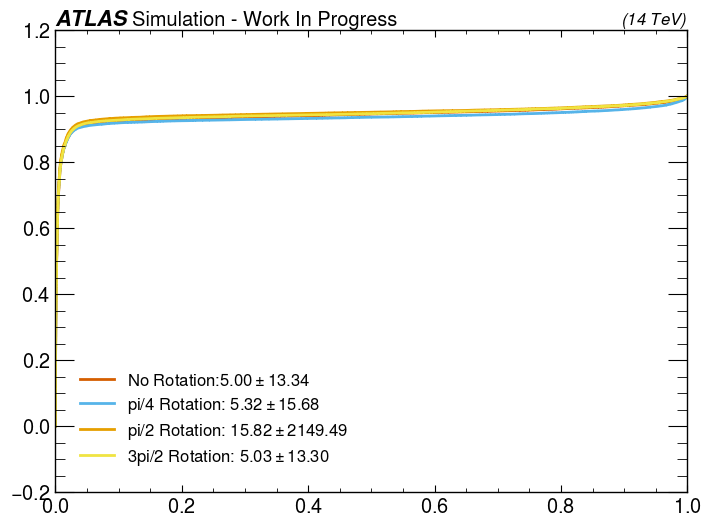

In [22]:
# Rotated losses
VAE3_ggf_pi2 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/phi_invariance_study/ggfpi2kl.npy")
VAE3_ggf_3pi4 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/phi_invariance_study/ggf3pi4kl.npy")
VAE3_ggf_pi4 = np.load("//home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/phi_invariance_study/ggfpi4kl.npy")
VAE3_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/ggF_kl_losses.npy")[:41000]
VAE3_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/testing_losses/jz0_kl_losses.npy")[:41000]
kl_cutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_tuning/l4/1e_1/signal_acceptance_rates/KLCutoff.npy")


# Labels
VAE3_jz0_labels = np.zeros_like(VAE3_jz0_scores)
VAE3_ggf_pi4_labels = np.ones_like(VAE3_ggf_pi4)
VAE3_ggf_pi2_labels =  np.ones_like(VAE3_ggf_pi2)
VAE3_ggf_3pi4_labels = np.ones_like(VAE3_ggf_3pi4)
VAE3_ggf_unrotated_labels = np.ones_like(VAE3_ggf_scores)

# Combined Losses
VAE3_ggf_unrotated_combined_losses = np.concatenate([VAE3_jz0_scores,VAE3_ggf_scores])
VAE3_ggf_pi2_combined_losses = np.concatenate([VAE3_jz0_scores,VAE3_ggf_pi2])
VAE3_ggf_pi4_combined_losses = np.concatenate([VAE3_jz0_scores,VAE3_ggf_pi4])
VAE3_ggf_3pi4_combined_losses = np.concatenate([VAE3_jz0_scores,VAE3_ggf_3pi4])

# Combined labels
VAE3_unrotated_rotation_combined_labels = np.concatenate([VAE3_jz0_labels, VAE3_ggf_unrotated_labels])
VAE3_pi2_rotation_combined_labels = np.concatenate([VAE3_jz0_labels, VAE3_ggf_pi2_labels])
VAE3_pi4_rotation_combined_labels = np.concatenate([VAE3_jz0_labels, VAE3_ggf_pi4_labels])
VAE3_3pi4_rotation_combined_labels = np.concatenate([VAE3_jz0_labels, VAE3_ggf_3pi4_labels])


VAE3_fpr_ggf_unrotated, VAE3_tpr_ggf_unrotated, VAE3_threshold_ggf_unrotated = roc_curve(VAE3_unrotated_rotation_combined_labels, VAE3_ggf_unrotated_combined_losses)
VAE3_fpr_ggf_pi4, VAE3_tpr_ggf_pi4, VAE3_threshold_ggf_pi4 = roc_curve(VAE3_pi4_rotation_combined_labels, VAE3_ggf_pi4_combined_losses)
VAE3_fpr_ggf_pi2, VAE3_tpr_ggf_pi2, VAE3_threshold_ggf_pi2 = roc_curve(VAE3_pi2_rotation_combined_labels, VAE3_ggf_pi2_combined_losses)
VAE3_fpr_ggf_3pi4, VAE3_tpr_ggf_3pi4, VAE3_threshold_ggf_3pi4 = roc_curve(VAE3_3pi4_rotation_combined_labels, VAE3_ggf_3pi4_combined_losses)

VAE3_ggf_unrotated_auc = auc(VAE3_fpr_ggf_unrotated, VAE3_tpr_ggf_unrotated)
VAE3_ggf_pi4_auc = auc(VAE3_fpr_ggf_pi4, VAE3_tpr_ggf_pi4)
VAE3_ggf_pi2_auc = auc(VAE3_fpr_ggf_pi2, VAE3_tpr_ggf_pi2)
VAE3_ggf_3pi4_auc = auc(VAE3_fpr_ggf_3pi4, VAE3_tpr_ggf_3pi4)

VAE3_ggf_scores_mean= np.mean(VAE3_ggf_scores)
VAE3_ggf_pi4_mean = np.mean(VAE3_ggf_pi4)
VAE3_ggf_pi2_mean = np.mean(VAE3_ggf_pi2)
VAE3_ggf_3pi4_mean = np.mean(VAE3_ggf_3pi4)

VAE3_ggf_scores_std = np.std(VAE3_ggf_scores)
VAE3_ggf_pi4_std = np.std(VAE3_ggf_pi4)
VAE3_ggf_pi2_std = np.std(VAE3_ggf_pi2)
VAE3_ggf_3pi4_std = np.std(VAE3_ggf_3pi4)


plt.plot(VAE3_fpr_ggf_unrotated,VAE3_tpr_ggf_unrotated, label = f"No Rotation:${VAE3_ggf_scores_mean:.2f}\pm{VAE3_ggf_scores_std:.2f}$ ")
plt.plot(VAE3_fpr_ggf_pi4,VAE3_tpr_ggf_pi4, label = f"pi/4 Rotation: ${VAE3_ggf_pi4_mean:.2f}\pm{VAE3_ggf_pi4_std:.2f}$ ")
plt.plot(VAE3_fpr_ggf_pi2,VAE3_tpr_ggf_pi2, label = f"pi/2 Rotation: ${VAE3_ggf_pi2_mean:.2f}\pm{VAE3_ggf_pi2_std:.2f}$")
plt.plot(VAE3_fpr_ggf_3pi4,VAE3_tpr_ggf_3pi4, label = f"3pi/2 Rotation: ${VAE3_ggf_3pi4_mean:.2f}\pm{VAE3_ggf_3pi4_std:.2f}$")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.legend()

z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(VAE3_pi2_rotation_combined_labels, VAE3_ggf_pi2_combined_losses,VAE3_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(VAE3_pi2_rotation_combined_labels, VAE3_ggf_pi4_combined_losses,VAE3_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(VAE3_pi2_rotation_combined_labels, VAE3_ggf_3pi4_combined_losses,VAE3_ggf_unrotated_combined_losses)
print(z,p_value)

0.8907528010113028
0.8904774693634742
0.8912647278405712
0.8908563691255206
-0.7748722206782017 0.4384151684759581


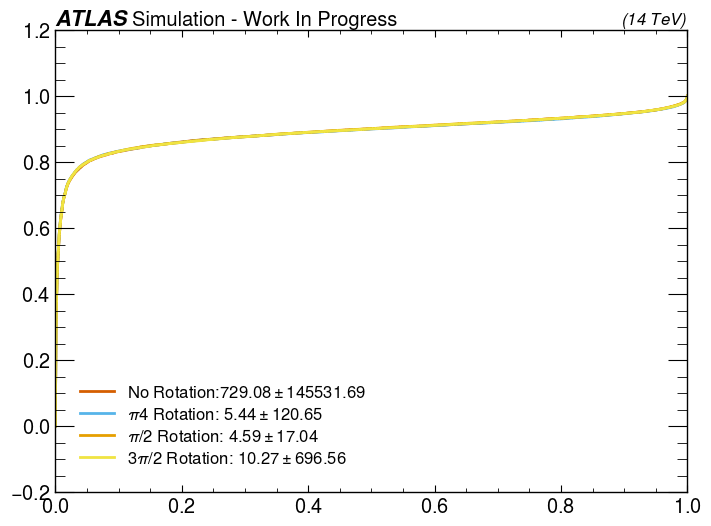

In [21]:
# Rotated losses
spvae_ggf_pi2 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/phi_invariance_study/ggfpi2kl.npy")
spvae_ggf_3pi4 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/phi_invariance_study/ggf3pi4kl.npy")
spvae_ggf_pi4 = np.load("//home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/phi_invariance_study/ggfpi4kl.npy")
spvae_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/ggF_kl_losses.npy")[:41000]
spvae_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/testing_losses/jz0_kl_losses.npy")[:41000]
kl_cutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/SparseVAE2/7e_2/signal_acceptance_rates/KLCutoff.npy")


# Labels
spvae_jz0_labels = np.zeros_like(spvae_jz0_scores)
spvae_ggf_pi4_labels = np.ones_like(spvae_ggf_pi4)
spvae_ggf_pi2_labels =  np.ones_like(spvae_ggf_pi2)
spvae_ggf_3pi4_labels = np.ones_like(spvae_ggf_3pi4)
spvae_ggf_unrotated_labels = np.ones_like(spvae_ggf_scores)

# Combined Losses
spvae_ggf_unrotated_combined_losses = np.concatenate([spvae_jz0_scores,spvae_ggf_scores])
spvae_ggf_pi2_combined_losses = np.concatenate([spvae_jz0_scores,spvae_ggf_pi2])
spvae_ggf_pi4_combined_losses = np.concatenate([spvae_jz0_scores,spvae_ggf_pi4])
spvae_ggf_3pi4_combined_losses = np.concatenate([spvae_jz0_scores,spvae_ggf_3pi4])

# Combined labels
spvae_unrotated_rotation_combined_labels = np.concatenate([spvae_jz0_labels, spvae_ggf_unrotated_labels])
spvae_pi2_rotation_combined_labels = np.concatenate([spvae_jz0_labels, spvae_ggf_pi2_labels])
spvae_pi4_rotation_combined_labels = np.concatenate([spvae_jz0_labels, spvae_ggf_pi4_labels])
spvae_3pi4_rotation_combined_labels = np.concatenate([spvae_jz0_labels, spvae_ggf_3pi4_labels])


spvae_fpr_ggf_unrotated, spvae_tpr_ggf_unrotated, spvae_threshold_ggf_unrotated = roc_curve(spvae_unrotated_rotation_combined_labels, spvae_ggf_unrotated_combined_losses)
spvae_fpr_ggf_pi4, spvae_tpr_ggf_pi4, spvae_threshold_ggf_pi4 = roc_curve(spvae_pi4_rotation_combined_labels, spvae_ggf_pi4_combined_losses)
spvae_fpr_ggf_pi2, spvae_tpr_ggf_pi2, spvae_threshold_ggf_pi2 = roc_curve(spvae_pi2_rotation_combined_labels, spvae_ggf_pi2_combined_losses)
spvae_fpr_ggf_3pi4, spvae_tpr_ggf_3pi4, spvae_threshold_ggf_3pi4 = roc_curve(spvae_3pi4_rotation_combined_labels, spvae_ggf_3pi4_combined_losses)

spvae_ggf_unrotated_auc = auc(spvae_fpr_ggf_unrotated, spvae_tpr_ggf_unrotated)
spvae_ggf_pi4_auc = auc(spvae_fpr_ggf_pi4, spvae_tpr_ggf_pi4)
spvae_ggf_pi2_auc = auc(spvae_fpr_ggf_pi2, spvae_tpr_ggf_pi2)
spvae_ggf_3pi4_auc = auc(spvae_fpr_ggf_3pi4, spvae_tpr_ggf_3pi4)


print(spvae_ggf_unrotated_auc)
print(spvae_ggf_pi4_auc)
print(spvae_ggf_pi2_auc)
print(spvae_ggf_3pi4_auc)


spvae_ggf_scores_mean= np.mean(spvae_ggf_scores)
spvae_ggf_pi4_mean = np.mean(spvae_ggf_pi4)
spvae_ggf_pi2_mean = np.mean(spvae_ggf_pi2)
spvae_ggf_3pi4_mean = np.mean(spvae_ggf_3pi4)

spvae_ggf_scores_std = np.std(spvae_ggf_scores)
spvae_ggf_pi4_std = np.std(spvae_ggf_pi4)
spvae_ggf_pi2_std = np.std(spvae_ggf_pi2)
spvae_ggf_3pi4_std = np.std(spvae_ggf_3pi4)


plt.plot(spvae_fpr_ggf_unrotated,spvae_tpr_ggf_unrotated, label = f"No Rotation:${spvae_ggf_scores_mean:.2f}\pm{spvae_ggf_scores_std:.2f}$ ")
plt.plot(spvae_fpr_ggf_pi4,spvae_tpr_ggf_pi4, label = f"$\pi4$ Rotation: ${spvae_ggf_pi4_mean:.2f}\pm{spvae_ggf_pi4_std:.2f}$ ")
plt.plot(spvae_fpr_ggf_pi2,spvae_tpr_ggf_pi2, label = f"$\pi/2$ Rotation: ${spvae_ggf_pi2_mean:.2f}\pm{spvae_ggf_pi2_std:.2f}$")
plt.plot(spvae_fpr_ggf_3pi4,spvae_tpr_ggf_3pi4, label = f"$3\pi/2$ Rotation: ${spvae_ggf_3pi4_mean:.2f}\pm{spvae_ggf_3pi4_std:.2f}$")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.legend()


z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(spvae_pi2_rotation_combined_labels, spvae_ggf_pi2_combined_losses,spvae_ggf_unrotated_combined_losses)
print(z,p_value)

z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(spvae_pi2_rotation_combined_labels, spvae_ggf_pi2_combined_losses,spvae_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(spvae_pi2_rotation_combined_labels, spvae_ggf_pi4_combined_losses,spvae_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(spvae_pi2_rotation_combined_labels, spvae_ggf_3pi4_combined_losses,spvae_ggf_unrotated_combined_losses)
print(z,p_value)

In [ ]:
# Rotated losses
nfvae_ggf_pi2 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/phi_invariance_study/ggfpi2kl.npy")
nfvae_ggf_3pi4 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/phi_invariance_study/ggf3pi4kl.npy")
nfvae_ggf_pi4 = np.load("//home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/phi_invariance_study/ggfpi4kl.npy")
nfvae_ggf_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/ggF_kl_losses.npy")[:41000]
nfvae_jz0_scores = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/testing_losses/jz0_kl_losses.npy")[:41000]
kl_cutoff = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/NFVAE1/NFBest/l4/4e_1/signal_acceptance_rates/KLCutoff.npy")


# Labels
nfvae_jz0_labels = np.zeros_like(nfvae_jz0_scores)
nfvae_ggf_pi4_labels = np.ones_like(nfvae_ggf_pi4)
nfvae_ggf_pi2_labels =  np.ones_like(nfvae_ggf_pi2)
nfvae_ggf_3pi4_labels = np.ones_like(nfvae_ggf_3pi4)
nfvae_ggf_unrotated_labels = np.ones_like(nfvae_ggf_scores)

# Combined Losses
nfvae_ggf_unrotated_combined_losses = np.concatenate([nfvae_jz0_scores,nfvae_ggf_scores])
nfvae_ggf_pi2_combined_losses = np.concatenate([nfvae_jz0_scores,nfvae_ggf_pi2])
nfvae_ggf_pi4_combined_losses = np.concatenate([nfvae_jz0_scores,nfvae_ggf_pi4])
nfvae_ggf_3pi4_combined_losses = np.concatenate([nfvae_jz0_scores,nfvae_ggf_3pi4])

# Combined labels
nfvae_unrotated_rotation_combined_labels = np.concatenate([nfvae_jz0_labels, nfvae_ggf_unrotated_labels])
nfvae_pi2_rotation_combined_labels = np.concatenate([nfvae_jz0_labels, nfvae_ggf_pi2_labels])
nfvae_pi4_rotation_combined_labels = np.concatenate([nfvae_jz0_labels, nfvae_ggf_pi4_labels])
nfvae_3pi4_rotation_combined_labels = np.concatenate([nfvae_jz0_labels, nfvae_ggf_3pi4_labels])


nfvae_fpr_ggf_unrotated, nfvae_tpr_ggf_unrotated, nfvae_threshold_ggf_unrotated = roc_curve(nfvae_unrotated_rotation_combined_labels, nfvae_ggf_unrotated_combined_losses)
nfvae_fpr_ggf_pi4, nfvae_tpr_ggf_pi4, nfvae_threshold_ggf_pi4 = roc_curve(nfvae_pi4_rotation_combined_labels, nfvae_ggf_pi4_combined_losses)
nfvae_fpr_ggf_pi2, nfvae_tpr_ggf_pi2, nfvae_threshold_ggf_pi2 = roc_curve(nfvae_pi2_rotation_combined_labels, nfvae_ggf_pi2_combined_losses)
nfvae_fpr_ggf_3pi4, nfvae_tpr_ggf_3pi4, nfvae_threshold_ggf_3pi4 = roc_curve(nfvae_3pi4_rotation_combined_labels, nfvae_ggf_3pi4_combined_losses)

nfvae_ggf_unrotated_auc = auc(nfvae_fpr_ggf_unrotated, nfvae_tpr_ggf_unrotated)
nfvae_ggf_pi4_auc = auc(nfvae_fpr_ggf_pi4, nfvae_tpr_ggf_pi4)
nfvae_ggf_pi2_auc = auc(nfvae_fpr_ggf_pi2, nfvae_tpr_ggf_pi2)
nfvae_ggf_3pi4_auc = auc(nfvae_fpr_ggf_3pi4, nfvae_tpr_ggf_3pi4)


print(nfvae_ggf_unrotated_auc)
print(nfvae_ggf_pi4_auc)
print(nfvae_ggf_pi2_auc)
print(nfvae_ggf_3pi4_auc)


nfvae_ggf_scores_mean= np.mean(nfvae_ggf_scores)
nfvae_ggf_pi4_mean = np.mean(nfvae_ggf_pi4)
nfvae_ggf_pi2_mean = np.mean(nfvae_ggf_pi2)
nfvae_ggf_3pi4_mean = np.mean(nfvae_ggf_3pi4)

nfvae_ggf_scores_std = np.std(nfvae_ggf_scores)
nfvae_ggf_pi4_std = np.std(nfvae_ggf_pi4)
nfvae_ggf_pi2_std = np.std(nfvae_ggf_pi2)
nfvae_ggf_3pi4_std = np.std(nfvae_ggf_3pi4)

print(nfvae_ggf_scores_std)
print(nfvae_ggf_pi4_std)
print(nfvae_ggf_pi2_std)
print(nfvae_ggf_3pi4_std)


plt.plot(nfvae_fpr_ggf_unrotated,nfvae_tpr_ggf_unrotated, label = f"No Rotation:${nfvae_ggf_scores_mean:.2f}\pm{nfvae_ggf_scores_std:.2f}$ ")
plt.plot(nfvae_fpr_ggf_pi4,nfvae_tpr_ggf_pi4, label = f"$\pi4$ Rotation: ${nfvae_ggf_pi4_mean:.2f}\pm{nfvae_ggf_pi4_std:.2f}$ ")
plt.plot(nfvae_fpr_ggf_pi2,nfvae_tpr_ggf_pi2, label = f"$\pi/2$ Rotation: ${nfvae_ggf_pi2_mean:.2f}\pm{nfvae_ggf_pi2_std:.2f}$")
plt.plot(nfvae_fpr_ggf_3pi4,nfvae_tpr_ggf_3pi4, label = f"$3\pi/2$ Rotation: ${nfvae_ggf_3pi4_mean:.2f}\pm{nfvae_ggf_3pi4_std:.2f}$")
mh.atlas.label('- Work In Progress',loc = 0, com = 14)
plt.legend()

z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(nfvae_pi2_rotation_combined_labels, nfvae_ggf_pi2_combined_losses,nfvae_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(nfvae_pi2_rotation_combined_labels, nfvae_ggf_pi4_combined_losses,nfvae_ggf_unrotated_combined_losses)
print(z,p_value)
z, p_value, ci_A, ci_B, auc_A, auc_B, info = Delong_test(nfvae_pi2_rotation_combined_labels, nfvae_ggf_3pi4_combined_losses,nfvae_ggf_unrotated_combined_losses)
print(z,p_value)